# From-Scratch RNN for Time-Series Forecasting

This Colab notebook implements a simple recurrent neural network without using `torch.nn.RNN`, `torch.nn.LSTM`, or `torch.nn.GRU`.

The goal is didactic: students can see how the hidden state is updated step by step. The task is one-step-ahead prediction on a synthetic time series.

## 1. Imports and reproducibility

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

seed = 666 # semilla para reproducibilidad
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Create a synthetic time series

We combine sinusoidal components and noise. This keeps the example simple while still producing a sequence with temporal structure.

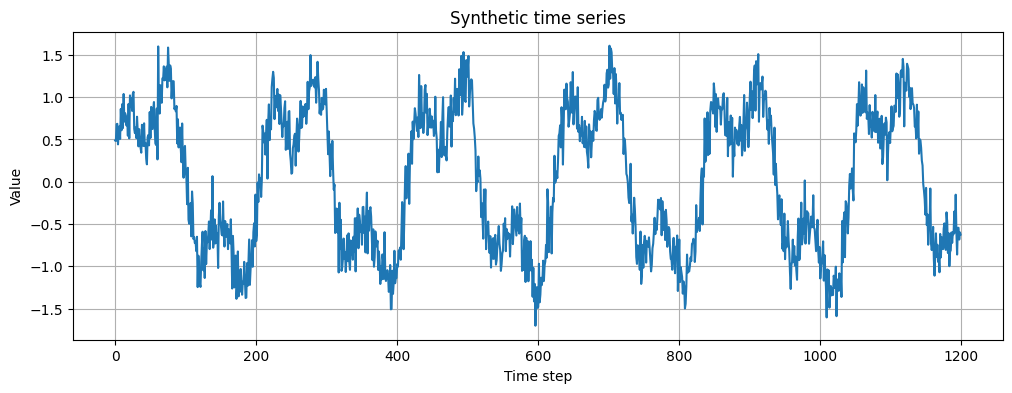

In [2]:
n_points = 1200 # conjunto X de datos secuenciales
t = np.arange(n_points)

series = (
    np.sin(0.03 * t) +
    0.5 * np.sin(0.09 * t + 0.7) +
    0.2 * np.random.randn(n_points)
).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(series)
plt.title("Synthetic time series")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## 3. Train/test split and standardization

Important: the mean and standard deviation are computed only with the training segment. This avoids information leakage from the test set.

In [3]:
train_size = int(0.8 * len(series))
train_raw = series[:train_size]
test_raw = series[train_size:]

mean = train_raw.mean()
std = train_raw.std()

series_norm = (series - mean) / std
train_norm = series_norm[:train_size]
test_norm = series_norm[train_size:]

print("Training points:", len(train_norm))
print("Testing points:", len(test_norm))
print("Training mean:", mean)
print("Training std:", std)

Training points: 960
Testing points: 240
Training mean: 0.06451324
Training std: 0.80684245


## 4. Sliding-window dataset

For one-step forecasting, each sample contains a window of past values and the target is the next value.

For example, with `window_size = 30`:

$[x_t, x_{t+1}, \dots, x_{t+29}] \rightarrow x_{t+30}$

In [4]:
def make_windows(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

window_size = 30
X_train, y_train = make_windows(train_norm, window_size)
X_test, y_test = make_windows(test_norm, window_size)

# RNN expected shape: batch x sequence_length x features
X_train = torch.tensor(X_train).unsqueeze(-1)
y_train = torch.tensor(y_train).unsqueeze(-1)
X_test = torch.tensor(X_test).unsqueeze(-1)
y_test = torch.tensor(y_test).unsqueeze(-1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([930, 30, 1])
y_train: torch.Size([930, 1])
X_test: torch.Size([210, 30, 1])
y_test: torch.Size([210, 1])


## 5. Data loaders

In [5]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

## 6. From-scratch RNN model

We implement the following equations manually:

$h_t = \tanh(x_t W_{xh} + h_{t-1}W_{hh} + b_h)$

$\hat{y} = h_T W_{hy} + b_y$

The prediction uses the final hidden state after reading the full input window.

In [6]:
class ScratchRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size

        # Trainable parameters of the RNN cell
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # Trainable parameters of the output layer
        self.W_hy = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_y = nn.Parameter(torch.zeros(output_size))

    def forward(self, x):
        # x shape: batch x sequence_length x input_size
        batch_size, sequence_length, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # Manual recurrence across time
        for step in range(sequence_length):
            x_t = x[:, step, :]
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)

        y_hat = h @ self.W_hy + self.b_y
        return y_hat

model = ScratchRNN(input_size=1, hidden_size=32, output_size=1).to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

ScratchRNN()
Trainable parameters: 1121


## 7. Training loop

The loop follows the standard deep learning routine: forward pass, loss computation, backward pass, optional gradient clipping, and optimizer update.

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 800
train_losses = []
test_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()

        # Helps prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_test_loss += loss.item() * xb.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train MSE: {avg_train_loss:.5f} | test MSE: {avg_test_loss:.5f}")

Epoch 001 | train MSE: 0.09207 | test MSE: 0.08345
Epoch 010 | train MSE: 0.08936 | test MSE: 0.09129
Epoch 020 | train MSE: 0.08427 | test MSE: 0.07678
Epoch 030 | train MSE: 0.08406 | test MSE: 0.07543
Epoch 040 | train MSE: 0.08548 | test MSE: 0.08030
Epoch 050 | train MSE: 0.08738 | test MSE: 0.08404
Epoch 060 | train MSE: 0.08206 | test MSE: 0.07511
Epoch 070 | train MSE: 0.08506 | test MSE: 0.07764
Epoch 080 | train MSE: 0.08697 | test MSE: 0.08360
Epoch 090 | train MSE: 0.08024 | test MSE: 0.08019
Epoch 100 | train MSE: 0.08390 | test MSE: 0.07701
Epoch 110 | train MSE: 0.08261 | test MSE: 0.07679
Epoch 120 | train MSE: 0.08176 | test MSE: 0.08234
Epoch 130 | train MSE: 0.08356 | test MSE: 0.07841
Epoch 140 | train MSE: 0.08431 | test MSE: 0.08042
Epoch 150 | train MSE: 0.08612 | test MSE: 0.08330
Epoch 160 | train MSE: 0.08191 | test MSE: 0.07652
Epoch 170 | train MSE: 0.08589 | test MSE: 0.08055
Epoch 180 | train MSE: 0.08973 | test MSE: 0.08068
Epoch 190 | train MSE: 0.08181 

## 8. Plot the learning curves

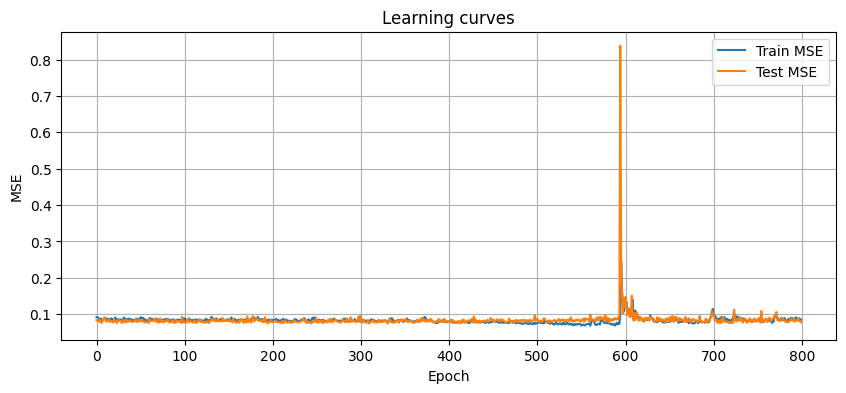

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(test_losses, label="Test MSE")
plt.title("Learning curves")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

## 9. Predictions on the test set

We transform normalized predictions back to the original scale.

In [10]:
model.eval()
with torch.no_grad():
    pred_test_norm = model(X_test.to(device)).cpu().numpy().squeeze()

y_test_norm_np = y_test.numpy().squeeze()

pred_test = pred_test_norm * std + mean
true_test = y_test_norm_np * std + mean

rmse = np.sqrt(np.mean((true_test - pred_test) ** 2))
mae = np.mean(np.abs(true_test - pred_test))
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")

Test RMSE: 0.2248
Test MAE:  0.1811


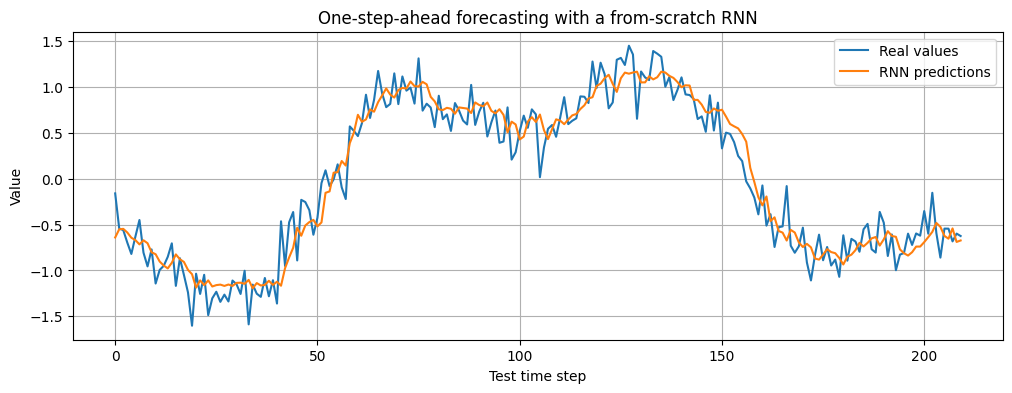

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(true_test[:250], label="Real values")
plt.plot(pred_test[:250], label="RNN predictions")
plt.title("One-step-ahead forecasting with a from-scratch RNN")
plt.xlabel("Test time step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

## 10. Optional: inspect how the hidden state evolves

This block visualizes a few hidden units over a single input window. It is useful for teaching that the hidden state changes as the sequence is processed.

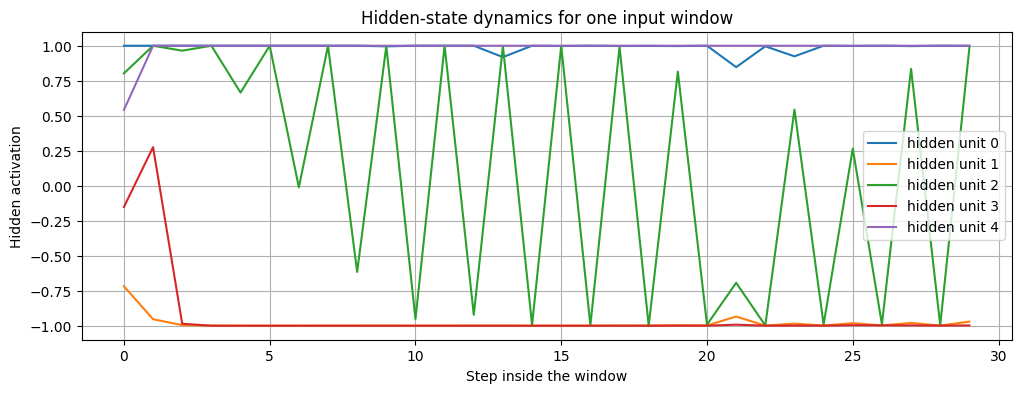

In [12]:
def collect_hidden_states(model, x_single):
    model.eval()
    with torch.no_grad():
        x_single = x_single.to(device)
        h = torch.zeros(1, model.hidden_size, device=device)
        states = []
        for step in range(x_single.shape[1]):
            x_t = x_single[:, step, :]
            h = torch.tanh(x_t @ model.W_xh + h @ model.W_hh + model.b_h)
            states.append(h.cpu().numpy().squeeze())
    return np.array(states)

sample = X_test[0:1]
states = collect_hidden_states(model, sample)

plt.figure(figsize=(12, 4))
for unit in range(5):
    plt.plot(states[:, unit], label=f"hidden unit {unit}")
plt.title("Hidden-state dynamics for one input window")
plt.xlabel("Step inside the window")
plt.ylabel("Hidden activation")
plt.legend()
plt.grid(True)
plt.show()